In [1]:
import pandas as pd
from data_preparation import Data_Preparation as dp
prep = dp()
df = prep.prepare_data_general()
X = df.drop(columns=['PumpTimeInSeconds','WaterLevel'])
y = df['PumpTimeInSeconds']
X

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
0,23.64,45.55,62.13,418.42,0.0,23.1,40.8,58.3,411.6
1,20.06,52.58,64.71,505.17,0.0,22.3,54.4,61.2,378.2
2,20.83,57.50,68.62,670.65,0.0,21.3,55.8,74.6,601.3
3,24.70,54.52,68.37,464.02,0.0,25.5,51.8,64.2,525.7
4,25.08,76.08,56.52,380.41,0.0,25.0,69.4,63.5,302.4
...,...,...,...,...,...,...,...,...,...
59995,17.44,66.04,65.18,796.64,68400.0,20.2,63.6,62.5,722.6
59996,22.09,55.34,75.23,414.67,331200.0,22.3,54.4,61.2,378.2
59997,23.79,37.59,63.52,311.17,741600.0,23.1,40.8,58.3,411.6
59998,24.10,49.18,65.71,659.18,43200.0,22.6,47.8,71.2,659.2


In [2]:
from sklearn.model_selection import  train_test_split
# Assuming X is your feature matrix and y is your target variable
# First split into training and temp (validation + test)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train,X_val,y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)
X_train

,Temperature,AirHumidity,SoilHumidity,LightIntensity,seconds_since_watering,OptimalTemperature,OptimalAirHumidity,OptimalSoilHumidity,OptimalLightIntensity
474,20.89,49.66,81.65,585.31,111600.0,22.6,47.8,71.2,659.2
35650,20.96,70.44,79.99,341.29,345600.0,21.9,68.8,75.3,310.0
9103,19.65,65.17,69.72,349.38,43200.0,22.4,62.1,72.9,392.5
16233,24.66,52.70,74.96,520.58,86400.0,22.6,47.8,71.2,659.2
7756,28.81,47.00,65.53,376.76,64800.0,25.0,55.0,67.7,371.4
...,...,...,...,...,...,...,...,...,...
54559,26.58,60.30,72.68,373.90,46800.0,22.4,62.1,72.9,392.5
58174,27.05,63.05,80.65,394.63,72000.0,24.8,65.5,72.4,540.1
18174,26.33,50.60,69.81,515.71,122400.0,25.5,51.8,64.2,525.7
2480,22.29,60.40,63.23,385.36,345600.0,22.3,54.4,61.2,378.2


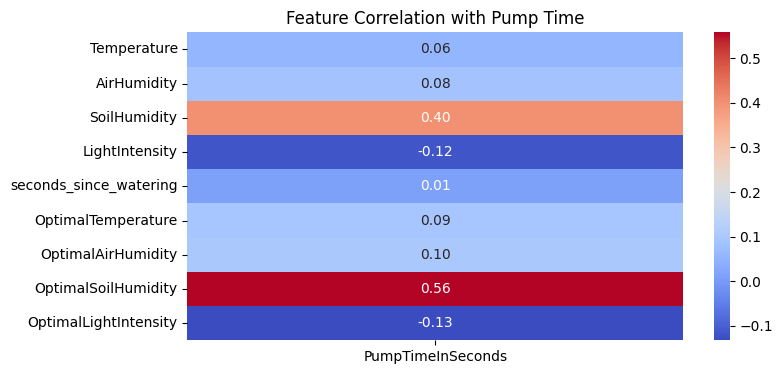

In [3]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# correlation of each feature with target
corr_series = X_train.corrwith(y_train)

plt.figure(figsize=(8, 4))
sns.heatmap(corr_series.to_frame(name='PumpTimeInSeconds'),
            annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation with Pump Time')
plt.show()

In [4]:
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X_train_scaled.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(4)
])

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

train_r2 = r2_score(y_train, model.predict(X_train_scaled))
val_r2   = r2_score(y_val,   model.predict(X_val_scaled))

print(f"Train set R²: {train_r2:.2f}")
print(f"Val set R²:   {val_r2:.2f}")

I0000 00:00:1778250188.340857   13136 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
W0000 00:00:1778250193.780083   13136 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 1s 445us/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step
Train set R²: 0.34
Val set R²:   0.32
